# Fully Connected Neural Networks 

This tutorial demonstrates the usage of fully connected neural-networks to classify 2-dimensional synthetic data. We implement the network using Keras and TensorFlow. Keras and TensorFlow are powerful frameworks that allow you to build many  deep-learning-based applications.

The goals of this tutorial are:
  - Introduce Keras and TensorFlow to implement fully connected neural network.
  - Illustrate the non-linear decision rules that multi-layer neural networks can achieve.
  
      
## Importing Python Libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

physical_devices = tf.config.experimental.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(physical_devices[0], True)

from tensorflow.keras.utils import to_categorical # Function to convert labels to one-hot encoding
from tensorflow.keras.models import Model 
from tensorflow.keras.layers import Dense, Activation,Input 
from tensorflow.keras.optimizers import SGD

import sys
## Adding dataset_utils to the system path so we can import it
MY_UTILS_PATH = '../Modules/'
if not MY_UTILS_PATH in sys.path:
    sys.path.append(MY_UTILS_PATH)
import dataset_utils 

IndexError: list index out of range

In [6]:
physical_devices = tf.config.experimental.list_physical_devices('GPU')
physical_devices
# tf.config.experimental.set_memory_growth(physical_devices[0], True)

[]

In [2]:
# The code here is a translation of the MATLAB code provided at
# https://www.mathworks.com/matlabcentral/fileexchange/41459-6-functions-for-generating-artificial-datasets

import numpy as np

def spirals(N = 1000, degrees = 570, start = 90, noise = 0.2):
    """
    Generate "two spirals" dataset with N instances. 
    Input:
    N -> Number of samples in the dataset
    degrees -> controls the length of the spirals
    start -> determines how far from the origin the spirals start, in degrees
    noise displaces the instances from the spiral. 0 is no noise, at 1 the
    spirals will start overlapping
    Output:
    data -> (Nx3) dataset: (xcoord,ycoord,label)
    """
    
    deg2grad = (2*np.pi)/360
    start = start*deg2grad
    
    #Number of samples in spirals 1 and 2
    N1 = int(np.floor(1.0*N/2))
    N2 = N - N1
    
    #Spiral 1
    n = start + np.sqrt(np.random.rand(N1,1))*degrees*deg2grad
    d1x =  -np.cos(n)*n + np.random.rand(N1,1)*noise                   
    d1y = np.sin(n)*n + np.random.rand(N1,1)*noise    
    
    spiral1 = np.concatenate((d1x,d1y,\
                             np.zeros((N1,1))),axis = 1)
    
    # Spiral 2
    n = start + np.sqrt(np.random.rand(N2,1))*degrees*deg2grad
    d2x = np.cos(n)*n+np.random.rand(N2,1)*noise
    d2y = -np.sin(n)*n + np.random.rand(N2,1)*noise
    spiral2 = np.concatenate((d2x,d2y,\
                             np.ones((N2,1))),axis = 1)
    
    #Concatenating the final data
    data = np.concatenate((spiral1,spiral2),axis = 0)
    return data


def concentric_clusters(N = 1000, r1 = 1, r2 = 5, w1 = 0.8, w2 = 1.0/3, arms = 64):
    """
    Generates two concentric circular clusters.
    Input:
    N -> Number of samples in the dataset
    r1 -> Radius cluster 1
    r2 -> Radius cluster 2
    w1 -> Cluster 1 weight
    w2 -> Cluster 2 weight
    arms -> Number of stripes (arms) in the circle
    Output:
    data -> (Nx3) dataset: (xcoord,ycoord,label)
    """
    
    #Number of samples in each cluster
    N1 = int(np.floor(1.0*N/2))
    N2 = N - N1
    
    phi1 = np.random.rand(N1,1) * 2 * np.pi;
    dist1 = r1 + 1.0*(np.random.randint(0,5,size =(N1,1)))/5*w1*r1
    d1x = dist1* np.cos(phi1) 
    d1y = dist1* np.sin(phi1) 
    cluster1 = np.concatenate((d1x,d1y,\
                             np.zeros((N1,1))),axis = 1)
    
    perarm = int(np.round(N2/arms))
    N2 = perarm*arms;
    radperarm = (2*np.pi)/arms;
    phi2 = 1.0*(np.arange(1,N2+1,dtype = int) - np.arange(1,N2+1,\
            dtype=int)%perarm)/perarm*(radperarm)
    dist2 = r2 * (1 - w2/2) + (r2*w2*np.arange(1,N2+1,\
            dtype=int)%perarm)/perarm
    d2x = dist2*np.cos(phi2)
    d2y = dist2*np.sin(phi2)
    cluster2 = np.concatenate((d2x[:,np.newaxis],d2y[:,np.newaxis],\
                             np.ones((N2,1))),axis = 1)  
    
    #Concatenating the final data
    data = np.concatenate((cluster1,cluster2),axis = 0)
    return data



def corners(N = 100,scale = 0,gapwidth = 2,cornerwidth = 2):
    """
    Generates for "corner" clusters .
    Input:
    N -> Number of samples in the dataset
    scale -> Corner scale
    gapwidth -> gap between corners
    cornerwidth -> corner width
    Output:
    data -> (Nx3) dataset: (xcoord,ycoord,label)
    """
    
    N = int(N/8)*8
    per_corner  = N//4
    
    xplusmin = np.concatenate((np.ones((per_corner,1)),\
                               -np.ones((per_corner,1)),\
                               np.ones((per_corner,1)),\
                               -np.ones((per_corner,1))),\
                               axis = 0)
                              
    yplusmin = np.concatenate((np.ones((per_corner,1)),\
                               -np.ones((2*per_corner,1)),\
                               np.ones((per_corner,1))),\
                               axis = 0)
    
    #Horizontal edge
    x = xplusmin[::2]*gapwidth+xplusmin[::2]*scale*(np.random.rand(2*per_corner).reshape(-1,1))
    
    y = yplusmin[::2]*gapwidth + cornerwidth*yplusmin[::2]*(np.random.rand(2*per_corner).reshape(-1,1))                          
    
    z = np.floor(np.arange(2*per_corner,dtype = int)/(per_corner*0.5))
    
    horizontal = np.concatenate((x,y,z[:,np.newaxis]),axis = 1)
                  
    # Vertical edge
    x2 = xplusmin[1::2]*gapwidth + cornerwidth*xplusmin[1::2]*\
                                 (np.random.rand(2*per_corner).reshape(-1,1))
    
    y2 = yplusmin[1::2]*gapwidth+yplusmin[1::2]*scale*\
                                 (np.random.rand(2*per_corner).reshape(-1,1))
    
    z2 = np.floor(np.arange(2*per_corner,dtype = int)/(per_corner*0.5))
    vertical = np.concatenate((x2,y2,z2[:,np.newaxis]),axis = 1)
    
    #Concatenating the final data
    data = np.concatenate((vertical,horizontal),axis = 0)
    return data



def crescent_full_moon(N = 1000,r1 = 5,r2 = 10,r3 = 15):
    """
    Generates 2 clusters. One shape as a full moon and the other as a crescent moon.
    Input:
    N -> Number of samples in the dataset
    r1 -> 
    r2 -> 
    r3 -> 
    Output:
    data -> (Nx3) dataset: (xcoord,ycoord,label)
    """

    N = int(N/4)*4
    N1 = int(N/4)
    N2 = N-N1   
     
    # Full moon
    phi1 = np.random.rand(N1,1)*2*np.pi
    R1 = np.sqrt(np.random.rand(N1, 1))
    moon = np.concatenate((np.cos(phi1)*R1*r1,np.sin(phi1)*R1*r1,\
                           np.zeros((N1,1))),axis = 1)
    # Crescent moon
    d = r3 - r2
    phi2 = np.pi + np.random.rand(N2,1)*np.pi
    R2 = np.sqrt(np.random.rand(N2,1))
    crescent = np.concatenate((np.cos(phi2)*(r2 + R2 * d),\
                               np.sin(phi2)*(r2 + R2 * d),\
                               np.ones((N2,1))),axis = 1)
    #concatenating the final data
    data = np.concatenate((moon,crescent),axis = 0)
    return data

> For the crescent moon, this is a nonlinear problem, so it is probably a good idea to add more layers. 

> good activity to do at home is to try addming more layers

> more layers means that the model is more powerful, has a better ability to learn the training data...

## Loading and Displaying a Synthetic 2D Dataset

In [3]:
#Generating a synthetic dataset with four classes
nsamples = 300

data = dataset_utils.corners(N = nsamples,scale = 0.5,gapwidth = 3,cornerwidth = 4) # linear dataset
#data = dataset_utils.crescent_full_moon(N = nsamples,r1 = 5,r2 = 10,r3 = 15) #non-linear dataset

# Separating features (X) and labels (Y)
Y = data[:,-1].astype(int) # Labels - last column of the data has labels
X = data[:,:-1] # Features

#Number of classes
k = np.unique(Y).size

colors = np.array(['r','y','b','g'])
#Displaying the dataset
plt.scatter(X[:,0],X[:,1],c=Y)

plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.title("Dataset")
plt.show()

NameError: name 'dataset_utils' is not defined

> sometimes you take pictures in a high dynamic range, so you need to scale them to the same range, because pictures have different dynamic ranges. This is important to consider if doing image processing where the dataset contains images produced by different devices

> We can scale. When scaling data we will want to scale the data on the statistics of your training set. 

## Train, Validation and Test Sets Split

In [3]:
# First we will shuffle the samples
indexes = np.arange(X.shape[0]) # creating a vector of indexes, and then perform a shuffle on the indexes
np.random.shuffle(indexes)
X = X[indexes,:]
Y = Y[indexes]

# Then, we split our data into train/val/test sets
train_split = int(0.5*Y.size) # 50% for train
val_split = int(0.75*Y.size)

X_train = X[:train_split,:]
Y_train = Y[:train_split]

X_val = X[train_split:val_split,:]
Y_val = Y[train_split:val_split]

X_test = X[val_split:,:]
Y_test = Y[val_split:]

C:\Users\rober\AppData\Local\Temp\ipykernel_25312\2020166094.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  train_split = np.int(0.5*Y.size)
C:\Users\rober\AppData\Local\Temp\ipykernel_25312\2020166094.py:9: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note li

## Data Normalization

In [ ]:
# min-max data normalization
x_train_min = X_train.min(axis = 0, keepdims = True)
x_train_max = X_train.max(axis = 0, keepdims = True)

X_train = (X_train - x_train_min)/(x_train_max - x_train_min)
X_val = (X_val - x_train_min)/(x_train_max - x_train_min)
X_test = (X_test - x_train_min)/(x_train_max - x_train_min)


#####################################################################################
#Activity suggestion:
# Change the min-max normalization above by standardization ((X - mean)/(std))
####################################################################################


#Displaying the normalized train set
plt.scatter(X_train[:,0],X_train[:,1],c=Y_train)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.title("Normalized Train Set")
plt.show()

NameError: name 'X_train' is not defined

## Representing Labels using one-hot-ecoding

> pytorch has an option to set this

> we do this mostly when we have multilabel problems

In [5]:
Y_oh_train = to_categorical(Y_train, k) 
Y_oh_val = to_categorical(Y_val, k) 
Y_oh_test = to_categorical(Y_test, k)
# Displaying the 5 first elemnts
print('Y_train[:5]:')
print(Y_train[:5])
print('\nY_oh_train[:5]=')
print(Y_oh_train[:5])

Y_train[:5]:
[1 1 3 1 2]

Y_oh_train[:5]=
[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]


## Defining a Fully Connected Neural Network with Keras

In [6]:
def my_model(k,learning_rate = 0.15):
    inputs = Input(shape=(2,))
    out1 = Dense(k, activation='softmax')(inputs) # this dense layer takes k = 4, one for each output
    model = Model(inputs=inputs, outputs=out1) # we can have models that take multiple inputs, and multiple outputs. if there are multiple inputs, we can define a list here.
    sgd = SGD(lr=learning_rate) # learning_rate = 0.15
    model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics = ["accuracy"]) # when we compile, we must specify the optimizer (loss function), binary_crossentropy for binary classification.
    return model

> crossentropy - you want this to go down, but difficult to interpret by value.

In [ ]:
model = my_model(k)
print(model.summary())

NameError: name 'my_model' is not defined

## Training the Model

In [8]:
batch_size = train_split
nb_epoch = 100
n = X_train.shape[0] # number of training examples
history = model.fit(X_train, Y_oh_train, validation_data=(X_val,Y_oh_val), \
                    batch_size=batch_size, epochs=nb_epoch,verbose=1)

Epoch 1/100
1/1 [==============================] - 3s 3s/step - loss: 1.3593 - accuracy: 0.2500 - val_loss: 1.2762 - val_accuracy: 0.3108
Epoch 2/100
1/1 [==============================] - 0s 27ms/step - loss: 1.3510 - accuracy: 0.2500 - val_loss: 1.2705 - val_accuracy: 0.3108
Epoch 3/100
1/1 [==============================] - 0s 33ms/step - loss: 1.3430 - accuracy: 0.2500 - val_loss: 1.2651 - val_accuracy: 0.3108
Epoch 4/100
1/1 [==============================] - 0s 28ms/step - loss: 1.3353 - accuracy: 0.2500 - val_loss: 1.2598 - val_accuracy: 0.3108
Epoch 5/100
1/1 [==============================] - 0s 28ms/step - loss: 1.3279 - accuracy: 0.2500 - val_loss: 1.2547 - val_accuracy: 0.3649
Epoch 6/100
1/1 [==============================] - 0s 30ms/step - loss: 1.3208 - accuracy: 0.2635 - val_loss: 1.2498 - val_accuracy: 0.3649
Epoch 7/100
1/1 [==============================] - 0s 28ms/step - loss: 1.3139 - accuracy: 0.2838 - val_loss: 1.2450 - val_accuracy: 0.3649
Epoch 8/100
1/1 [=====

## Prininting Loss and estimated weights (Ws)

Final loss (cross-entropy and accuracy): [0.956568717956543, 1.0]

Layer 0
Bias:
 [-0.810896    0.6755656   0.20898847 -0.07365812]
W:
 [[ 1.4522017  -0.04433976  1.060782   -0.5241521 ]
 [ 1.4170763  -0.69065815 -0.4236062   1.587277  ]]



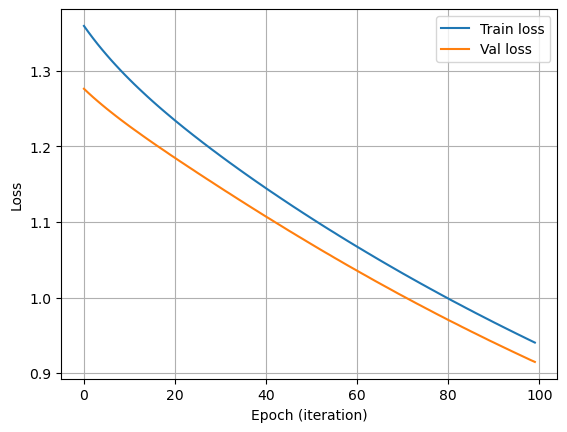

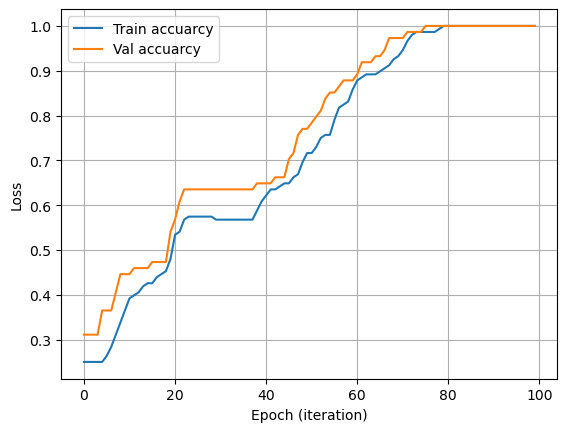

In [9]:
loss = model.evaluate(X_test, Y_oh_test, verbose=0)
print('Final loss (cross-entropy and accuracy):',loss)
print()
W = model.get_weights()
for ii in range(len(W)//2):
    print("Layer %d" %ii)
    print('Bias:\n', W[2*ii + 1])
    print('W:\n', W[2*ii])
    print()

plt.plot(history.history['loss'], label = "Train loss")
plt.plot(history.history['val_loss'], label = "Val loss")
plt.xlabel("Epoch (iteration)")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


plt.plot(history.history['accuracy'], label = "Train accuarcy")
plt.plot(history.history['val_accuracy'], label = "Val accuarcy")
plt.xlabel("Epoch (iteration)")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

> If the loss is still going down, we will want to keep training until the loss stops going down

> Why use crossentropy instead of accuracy for your loss function?

## Classifier Decision Boundary

117/117 [==============================] - 0s 1ms/step


C:\Users\rober\AppData\Local\Temp\ipykernel_25312\2289979409.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_train[:,0], X_train[:,1], c=colors[Y_train], edgecolors='k', cmap=plt.cm.Paired)


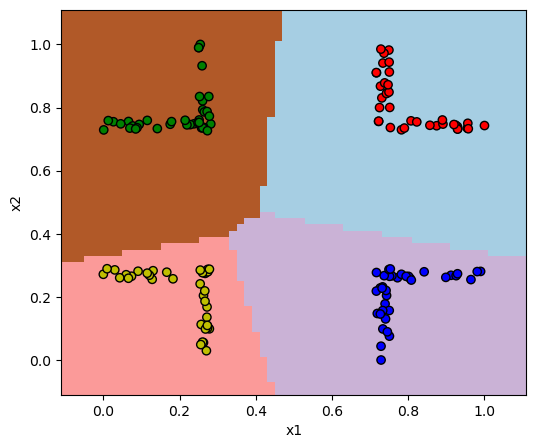

In [10]:
h = .02  # step size in the mesh
slack = 0.1
# Calcula a grade para o espaço de atributos

x_min, x_max = X_train.min(axis=0) - slack, X_train.max(axis=0) + slack
xx, yy = np.meshgrid(np.arange(x_min[0], x_max[0], h), np.arange(x_min[1], x_max[1], h))
X_grid = np.c_[xx.ravel(), yy.ravel()]

# Prediction of all samples in our grid
Z = model.predict(X_grid).argmax(axis = 1)
Z = Z.reshape(xx.shape)

# Display decision boundary
plt.figure(1, figsize=(6, 5))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Display training samples
plt.scatter(X_train[:,0], X_train[:,1], c=colors[Y_train], edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

## Suggested activities
- Repeat the example without normalizing the data or using standardization (i.e., subtract from the mean and divide by the standard-deviation);
- Experiment with other datasets
- Change the neural network architecture
- ...